In [1]:
from __future__ import annotations
from typing import List, Set
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

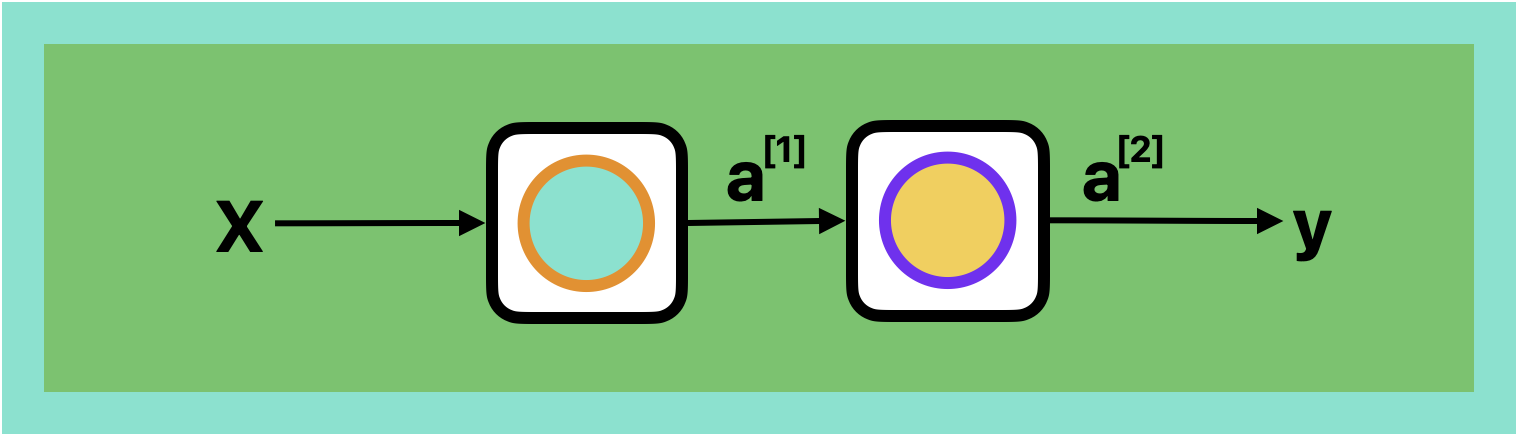

In [2]:
from typing import Tuple


class Tensor:
    def __init__(self, value: float, label: str = "", _prev: Set[Tensor] = set()):
        self.value = value
        self._prev = _prev
        self.grad = 0.0
        self._backward = lambda: None
        self.label = label if label != "" else str(value)

    def update(self, lr):
        self.value -= self.grad * lr

    def backward(self):
        # Topological Sort
        topo: List[Tensor] = []
        visited: Set[Tensor] = set()
        stack: List[Tuple[Tensor, bool]] = [(self, False)]

        while stack:
            node, processed = stack.pop()

            if processed:
                topo.append(node)
            elif node not in visited:
                visited.add(node)
                stack.append((node, True))
                for child in node._prev:
                    if child not in visited:
                        stack.append((child, False))

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __repr__(self) -> str:
        # return f"Tensor(label={self.label}, value={self.value}, grad={self.grad})"
        return f"{self.value}"

    def _repr_html_(self) -> str:
        """Renders an ultra-modern, dark-themed interactive card layout."""
        style = """
        <style>
            .dark-tensor-box {
                font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace;
                margin: 8px 0;
                background: #1e1e24;
                border: 1px solid #2d2d34;
                border-radius: 8px;
                overflow: hidden;
                max-width: 480px;
                box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.2), 0 2px 4px -1px rgba(0, 0, 0, 0.14);
            }
            .dark-tensor-details[open] {
                border-bottom: 2px solid #6366f1;
            }
            .dark-tensor-summary {
                background: #25252d;
                padding: 10px 14px;
                cursor: pointer;
                user-select: none;
                font-weight: 600;
                color: #e2e8f0;
                font-size: 13px;
                display: flex;
                align-items: center;
                transition: background 0.2s ease;
            }
            .dark-tensor-summary:hover {
                background: #2a2a35;
            }
            .dark-tensor-summary::-webkit-details-marker {
                color: #6366f1;
                margin-right: 6px;
            }
            .dark-tensor-content {
                padding: 12px 16px;
                background: #19191e;
                font-size: 12px;
            }
            .dark-tensor-row {
                display: flex;
                justify-content: space-between;
                padding: 4px 0;
                border-bottom: 1px solid #24242b;
            }
            .dark-tensor-row:last-child {
                border-bottom: none;
            }
            .dark-tensor-key {
                color: #94a3b8;
            }
            .dark-tensor-val {
                font-weight: bold;
            }
            .val-label { color: #38bdf8; }   /* Cyber blue */
            .val-data  { color: #4ade80; }   /* Emerald green */
            .val-grad  { color: #f87171; }   /* Crimson red */
        </style>
        """

        display_label = self.label if self.label else "None"

        return f"""
        {style}
        <div class="dark-tensor-box">
            <details class="dark-tensor-details">
                <summary class="dark-tensor-summary">Tensor(label={display_label})</summary>
                <div class="dark-tensor-content">
                    <div class="dark-tensor-row">
                        <span class="dark-tensor-key">label</span>
                        <span class="dark-tensor-val val-label">"{display_label}"</span>
                    </div>
                    <div class="dark-tensor-row">
                        <span class="dark-tensor-key">value</span>
                        <span class="dark-tensor-val val-data">{self.value}</span>
                    </div>
                    <div class="dark-tensor-row">
                        <span class="dark-tensor-key">grad</span>
                        <span class="dark-tensor-val val-grad">{self.grad}</span>
                    </div>
                </div>
            </details>
        </div>
        """

    def __radd__(self, other: Tensor | float):
        return self + other

    def __add__(self, other: Tensor | float):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.value + other.value, f"({self.label} + {other.label})", {self, other}
        )

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out

    def __neg__(self):
        out = self * Tensor(-1)
        return out

    def __sub__(self, other: Tensor | float):
        out = self + -other
        return out

    def __mul__(self, other: Tensor | float):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(
            self.value * other.value, f"{self.label} * {other.label}", {self, other}
        )

        def _backward():
            self.grad += out.grad * other.value
            other.grad += out.grad * self.value

        out._backward = _backward

        return out

    def __rmul__(self, other: Tensor | float):
        return self * other

    def __pow__(self, n: int):
        out = Tensor(
            self.value**n,
            f"{self.label} ** {n}",
            {self},
        )

        def _backward():
            self.grad += out.grad * n * self.value ** (n - 1)

        out._backward = _backward
        return out

    def __truediv__(self, other: Tensor | float):
        other = other if isinstance(other, Tensor) else Tensor(other)
        return self * other**-1

In [3]:
def train(X, y, n_iters=100, lr=0.005):
    tensorizer = np.vectorize(Tensor)

    m, n = X.shape
    np.random.seed(123)
    w1 = tensorizer(np.random.random(n))
    b1 = Tensor(np.random.random())
    w2 = tensorizer(np.array([1.0]))
    b2 = Tensor(np.random.random())

    cost_history = []

    parameters = list(w1) + [b1] + list(w2) + [b2]

    for epoch in tqdm(range(n_iters)):
        for p in parameters:
            p.grad = 0.0

        a1 = X @ w1.reshape(-1, 1) + b1
        a2 = a1 @ w2.reshape(-1, 1) + b2
        L = 1 / 2 * (a2.reshape(-1) - y) ** 2
        J = np.sum(L) / m

        cost_history.append(J.value)
        J.backward()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1:>5} | Cost: {J.value:>10.5f}")

        for p in parameters:
            p.update(lr=lr)

    return w1, b1, w2, b2, cost_history

In [4]:
def predict(X, w1, b1, w2, b2):
    a1 = X @ w1.reshape(-1, 1) + b1
    a2 = a1 @ w2.reshape(-1, 1) + b2

    return a2.reshape(-1)

In [5]:
df = pd.read_csv("datasets/winequality-white.csv", sep=";")
input_scaler = StandardScaler()

train_X = df.iloc[:3000, :-1].to_numpy()
train_y = df.iloc[:3000, -1:].to_numpy().reshape(-1)
test_X = df.iloc[3000:, :-1].to_numpy()
test_y = df.iloc[3000:, -1:].to_numpy().reshape(-1)

scaled_train_X = input_scaler.fit_transform(train_X)

In [6]:
w1, b1, w2, b2, cost_history = train(scaled_train_X, train_y, n_iters=100, lr=0.2)

 10%|█         | 10/100 [00:14<02:12,  1.48s/it]

Epoch    10 | Cost:    0.31428


 20%|██        | 20/100 [00:29<01:58,  1.48s/it]

Epoch    20 | Cost:    0.29771


 30%|███       | 30/100 [00:43<01:39,  1.42s/it]

...

Epoch    80 | Cost:    0.29513


 90%|█████████ | 90/100 [02:11<00:14,  1.40s/it]

Epoch    90 | Cost:    0.29497


100%|██████████| 100/100 [02:25<00:00,  1.45s/it]

Epoch   100 | Cost:    0.29484


In [7]:
scaled_test_X = input_scaler.transform(test_X)

p = predict(scaled_test_X, w1, b1, w2, b2)

n_corrects = 0
n_test_samples = len(test_X)

for i, y_hat in enumerate(p):
    if np.abs(y_hat.value - test_y[i]) <= .5:
        n_corrects += 1

print(f"Accuracy(±.5): {n_corrects / n_test_samples:.2%}")

p[0]

Accuracy(±.5): 51.48%


6.282325648807608

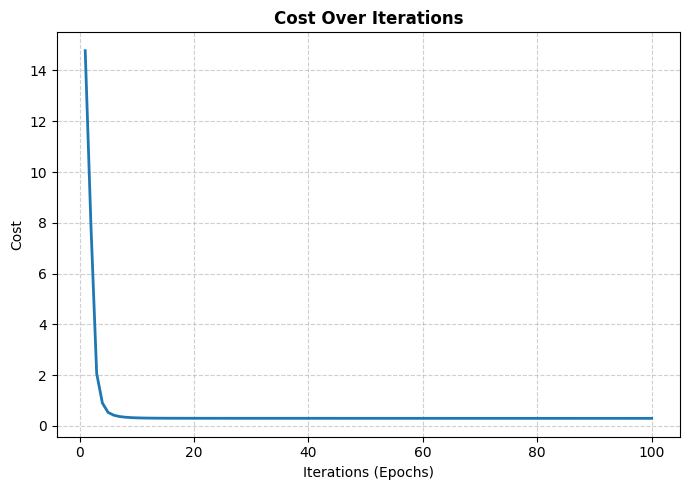

In [8]:
iter_range = range(1, len(cost_history) + 1)

plt.figure(figsize=(7, 5))
plt.plot(iter_range, cost_history, linewidth=2, label="Training Cost")

plt.title("Cost Over Iterations", fontweight="bold")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Cost")

plt.grid(linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()